In [3]:
import numpy as np
import matplotlib.pyplot as plt
import forte2
import psi4

In [4]:
#Hartree Fock with Psi4
psi4.set_memory('500 MB')

n2 = psi4.geometry("""
N 	0.0000 	0.0000 	0.0000
N 	0.0000 	0.0000 	1.0977
""")

psi4.energy('scf/cc-pvdz')


  Memory set to 476.837 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'function_kwargs': {}}
Compute energy(): method=scf, basis=cc-pvdz, molecule=default, nre=23.621830484494858
   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 09:50:45 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RHF Reference
                        1 Threads,    476 MiB

-108.9538210082401

In [5]:
#iterating over a list of bond lengths using a formatted string
N2_rlist = [0.70,0.80,0.90,0.95,1.00,1.05,1.0977,1.15,1.20,1.25,1.30,1.35,1.40,1.50,1.60, 1.70, 1.80, 1.90,2.00,2.20, 2.40, 2.60, 2.80, 3.00,3.20, 3.40, 3.60, 3.80, 4.00, 4.20, 4.40, 4.60, 4.80, 5.00]
HF_elist = []

for i in range(0,len(N2_rlist)):
    psi4.set_memory('500 MB')
    
    n2 = psi4.geometry(f"""
    N 	0.0000 	0.0000 	0.0000 
    N  0.0000 	0.0000 	{N2_rlist[i]}
    """)
    
    psi4.set_options({
        "basis": "cc-pvdz",
        "df_basis_scf": "cc-pvtz-jkfit",
        "scf__reference": "uhf",
        "print": 0})
    
    E = psi4.energy('scf')
    HF_elist.append(E)

print(HF_elist)


  Memory set to 476.837 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__INTS_TOLERANCE': 1e-12, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'function_kwargs': {}}
Compute energy(): method=scf, basis=cc-pvdz, molecule=default, nre=37.04240474690001


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 09:50:49 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

   => Loading Basis Set <=

    Name: CC-PVTZ-JKFIT
    Role: JKFIT
    Keyword: DF_BASIS_SCF
    atoms 1-2 entry N          line   177 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvtz-jkfit.gbs 

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.349 GiB. 
  SCF_SUBTYPE=INCORE selected. In-core MEM_DF algorithm will be used.
  Using in-core AOs.


  ==> Pre-Iterations <==

  ==> Iterations <==

                           Total Energy        Delta E     RMS |[F,P]|

   @DF-UHF iter SAD:  -11

Predicted Equilibrium Bond Length: 1.0898 A
Known Equilibrium Bond Length: 1.0977 A
Predicted Bond Dissociation Energy: 25.8896 eV
Known Bond Dissociation Energy: 9.759 eV


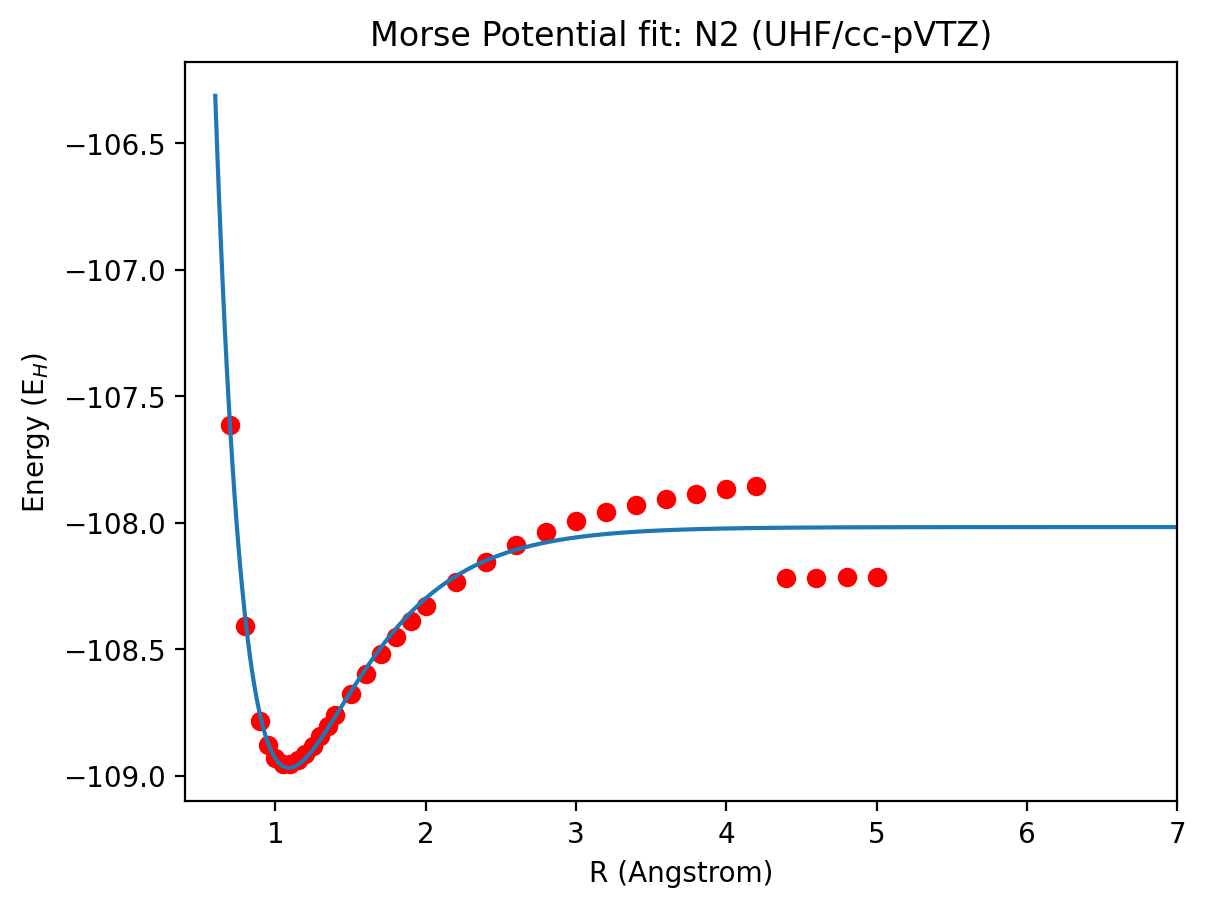

In [6]:
from scipy.optimize import curve_fit
#xdata: array of rvals
xdata=np.array(N2_rlist)
ydata=HF_elist
#ydata: list of energy

t=np.linspace(0.6,7.0,500)

tstart = [1, 1, 1, -100]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt, pcov = curve_fit(ms, xdata, ydata, p0 = tstart,  maxfev=40000000)
#print(popt)
yfit = ms(t, popt[0], popt[1], popt[2], popt[3])

plt.plot(xdata, ydata,"ro")
plt.plot(t, yfit)
plt.title("Morse Potential fit: N2 (UHF/cc-pVTZ)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.xlim(0.4,7.0)

dissociation_energy=(-min(yfit)+yfit[499])*27.211399

print(f"Predicted Equilibrium Bond Length: {popt[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.0977 A")

print(f"Predicted Bond Dissociation Energy: {dissociation_energy:.4f} eV")
print("Known Bond Dissociation Energy: 9.759 eV")


In [7]:
DFT_elist = []

for i in range(0,len(N2_rlist)):
    psi4.set_memory('500 MB')
    
    n2 = psi4.geometry(f"""
    N 	0.0000 	0.0000 	0.0000 
    N  0.0000 	0.0000 	{N2_rlist[i]}
    """)
    
    psi4.set_options({
        "basis": "cc-pvdz",
        "df_basis_scf": "cc-pvtz-jkfit",
        "scf__reference": "UKS",
        "print": 0})
    
    E = psi4.energy('b3lyp')
    DFT_elist.append(E)

print(DFT_elist)


  Memory set to 476.837 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__INTS_TOLERANCE': 1e-12, 'PRINT': 0, 'SCF__REFERENCE': 'UKS', 'function_kwargs': {}}


Compute energy(): method=b3lyp, basis=cc-pvdz, molecule=default, nre=37.04240474690001
   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 09:51:03 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

   => Loading Basis Set <=

    Name: CC-PVTZ-JKFIT
    Role: JKFIT
    Keyword: DF_BASIS_SCF
    atoms 1-2 entry N          line   177 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvtz-jkfit.gbs 

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.315 GiB. 
  SCF_SUBTYPE=INCORE selected. In-core MEM_DF algorithm will be used.
  Using in-core AOs.


  ==> Pre-Iterations <==

  ==> Iterations <==

          

Predicted Equilibrium Bond Length: 1.1243 A
Known Equilibrium Bond Length: 1.0977 A
Predicted Bond Dissociation Energy: 18.5722 eV
Known Bond Dissociation Energy: 9.759 eV


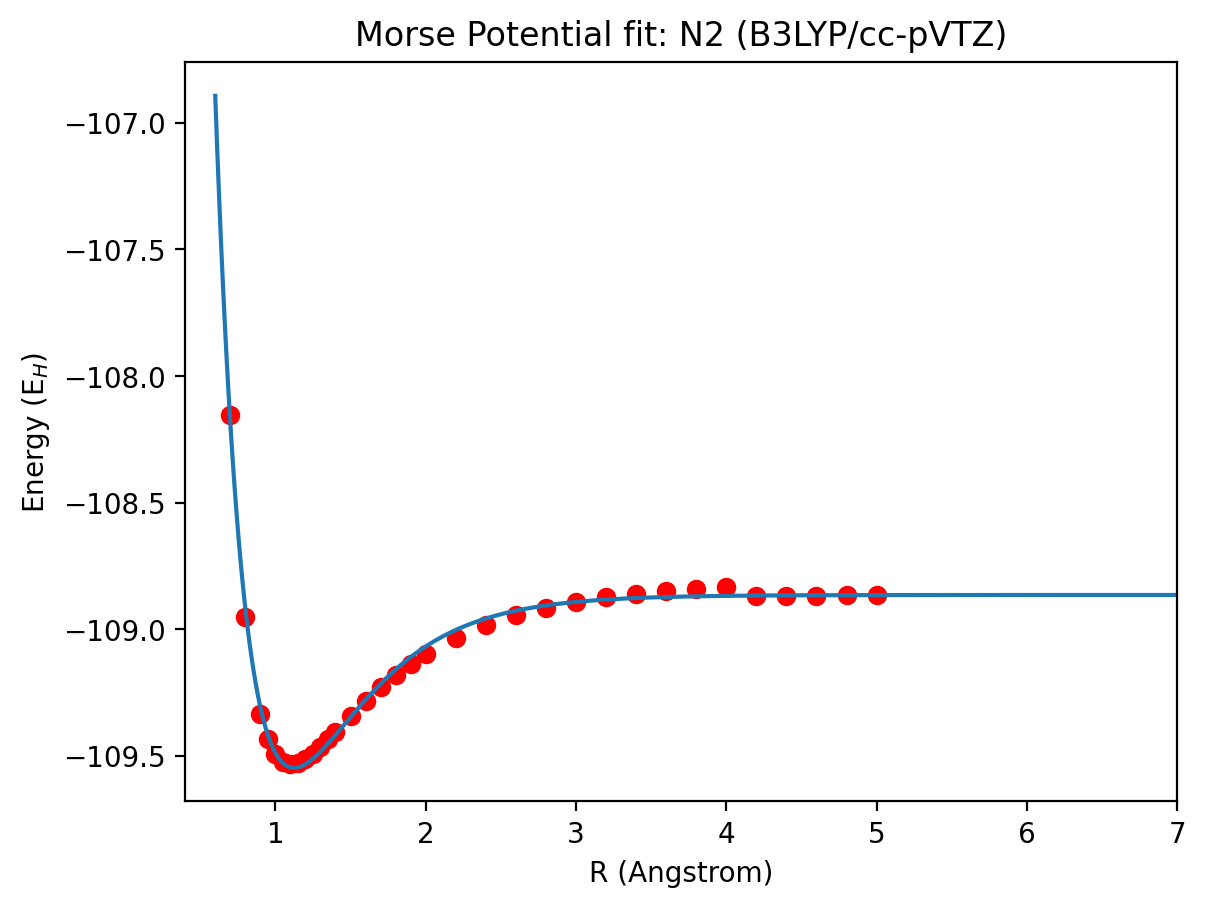

In [8]:
xdata2=np.array(N2_rlist)
ydata2=DFT_elist

t=np.linspace(0.6,7.0,500)

tstart = [1, 1, 1, -100]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt, pcov = curve_fit(ms, xdata2, ydata2, p0 = tstart,  maxfev=40000000)
#print(popt)
yfit = ms(t, popt[0], popt[1], popt[2], popt[3])

plt.plot(xdata2, ydata2,"ro")
plt.plot(t, yfit)
plt.title("Morse Potential fit: N2 (B3LYP/cc-pVTZ)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.xlim(0.4,7.0)

dissociation_energy=(-min(yfit)+yfit[499])*27.211399

print(f"Predicted Equilibrium Bond Length: {popt[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.0977 A")

print(f"Predicted Bond Dissociation Energy: {dissociation_energy:.4f} eV")
print("Known Bond Dissociation Energy: 9.759 eV")


In [9]:
psi4.core.clean() 

N2_rlist = [0.70,0.80,0.90,0.95,1.00,1.05,1.0977,1.15,1.20,1.30,1.40,1.50,1.60, 1.70, 1.80, 1.90, 2.00,2.20,2.80,3.00,3.20,3.40]
CCSD_elist = []

for i in range(0,len(N2_rlist)):
    psi4.core.clean() 

    psi4.set_memory('800 MB')
    
    n2 = psi4.geometry(f"""
    N 	0.0000 	0.0000 	0.0000 
    N  0.0000 	0.0000 	{N2_rlist[i]}
    """)
    
    psi4.set_options({
        "basis": "cc-pvdz",
        "df_basis_scf": "cc-pvtz-jkfit",
        "scf__reference": "UHF",
        "maxiter":100,
        "print": 0})
    
    E = psi4.energy('ccsd')
    CCSD_elist.append(E)

print(CCSD_elist)


  Memory set to 762.939 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'function_kwargs': {}}
Compute energy(): method=ccsd, basis=cc-pvdz, molecule=default, nre=37.04240474690001
   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 09:51:36 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

  Using in-core PK algorithm.
   Calculation information:
      Number of atoms:                   2
      Number of AO shells:              12
      Number of primitives:             44
   

In [10]:
psi4.core.clean() 

psi4.set_memory('800 MB')
    
n2 = psi4.geometry(f"""
N 	0.0000 	0.0000 	0.0000 
N  0.0000 	0.0000 	3.40
""")
    
psi4.set_options({
    "basis": "cc-pvdz",
    "df_basis_scf": "cc-pvtz-jkfit",
    "scf__reference": "UHF",
    "maxiter":100,
    "print": 0})
    
E = psi4.energy('ccsd')


  Memory set to 762.939 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'CCTRANSORT__WFN': 'CCSD', 'function_kwargs': {}}
Compute energy(): method=ccsd, basis=cc-pvdz, molecule=default, nre=7.626377447891175


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 09:52:23 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

  Using in-core PK algorithm.
   Calculation information:
      Number of atoms:                   2
      Number of AO shells:              12
      Number of primitives:             44
      Number of atomic orbitals:        30
      Number of basis functions:        28

      Integral cutoff                 1.00e-12
      Number of threads:                 1

  Performing in-core PK
  Using 165242 doubles for integral storage.
  We computed 2940 shell quartets total.
  Whereas there are 3081 unique shell qua

Predicted Equilibrium Bond Length: 1.0867 A
Known Equilibrium Bond Length: 1.0977 A
Predicted Bond Dissociation Energy: 8.1715 eV
Known Bond Dissociation Energy: 9.759 eV


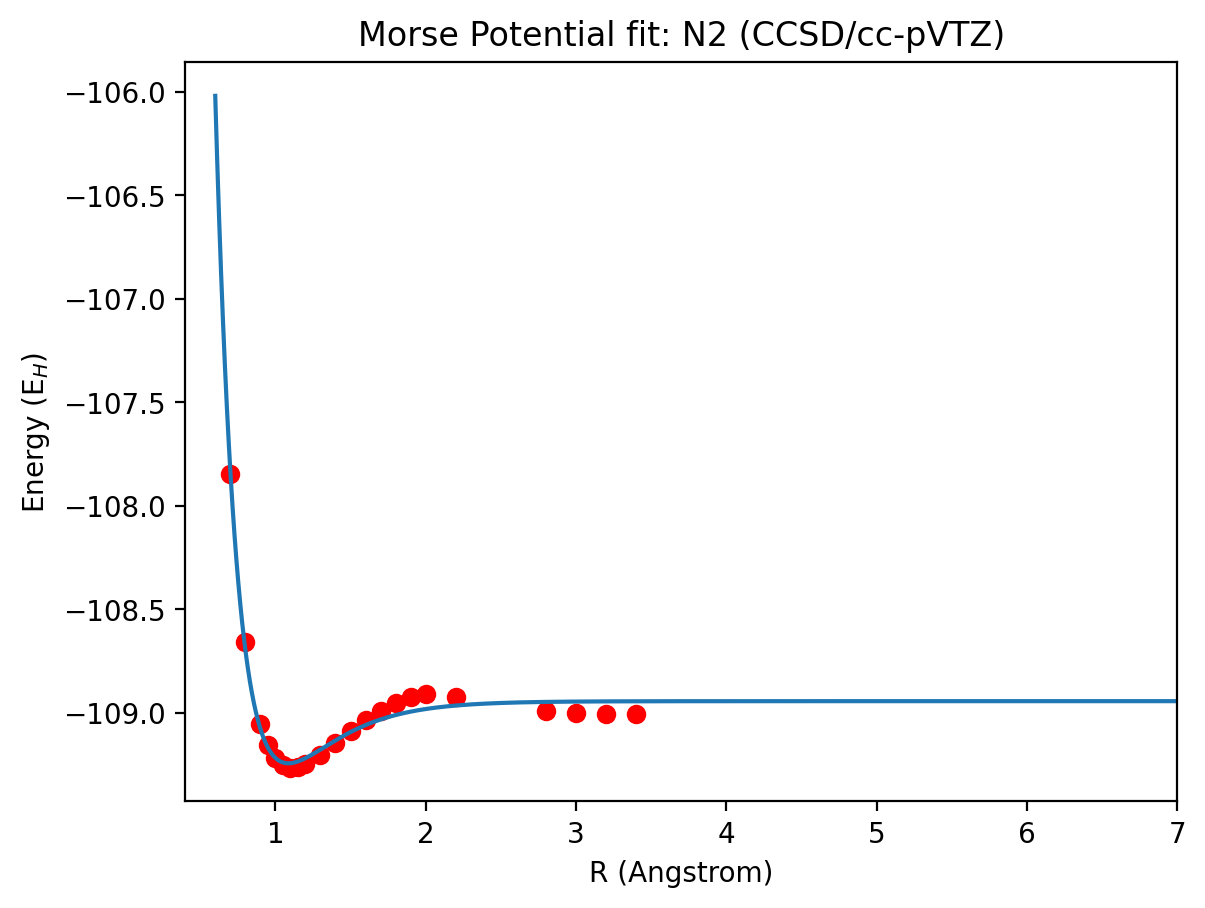

In [11]:
xdata2=np.array(N2_rlist)
ydata2=CCSD_elist

t=np.linspace(0.6,7.0,500)

tstart = [0.1, 4, 1.10, -109.3]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt, pcov = curve_fit(ms, xdata2, ydata2, p0 = tstart,  maxfev=40000000)
#print(popt)
yfit = ms(t, popt[0], popt[1], popt[2], popt[3])

plt.plot(xdata2, ydata2,"ro")
plt.plot(t, yfit)
plt.title("Morse Potential fit: N2 (CCSD/cc-pVTZ)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.xlim(0.4,7.0)

dissociation_energy=(-min(yfit)+yfit[499])*27.211399

print(f"Predicted Equilibrium Bond Length: {popt[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.0977 A")

print(f"Predicted Bond Dissociation Energy: {dissociation_energy:.4f} eV")
print("Known Bond Dissociation Energy: 9.759 eV")

In [12]:
N2_rlist = [0.70,0.75,0.80,0.85,0.90,0.95,1.00,1.05,1.0977,1.15,1.20,1.30,1.40,1.50,1.60, 1.70, 1.80, 1.90, 2.00, 2.20, 2.40,2.60, 2.80, 3.00,3.20, 3.40, 3.60, 3.80, 4.00, 4.20, 4.40, 4.60, 4.80, 5.00]
CAS_elist_0 = []
CAS_elist_1 = []

for i in range(0,len(N2_rlist)):
    xyz = f"""
    N 0.000 0.000 0.000
    N 0.000 0.000 {N2_rlist[i]}
    """

    system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

    rhf = forte2.RHF(charge=0)(system)
    rhf.run()

    #norb = rhf.nmo
    #orbitals = sorted(list(set(range(norb))))
    #print(orbitals)

    ci = forte2.CISolver(forte2.State(nel=14, multiplicity=1, ms=0.0),
        active_orbitals=6,
        core_orbitals=4,
        nroots=6
    )
    mc = forte2.MCOptimizer(ci)(rhf)
    mc.run()
    CAS_elist_0.append(ci.E[0])
    CAS_elist_1.append(ci.E[1])


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   0.00000000   1.32280829
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 3.266e+00
  Min eigenvalue: 8.208e-04
  Condition number: 3.980e+03
  Inverse condition number: 2.513e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 8.208e-04
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 158
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis function

Predicted Equilibrium Bond Length: 1.1166 A
Known Equilibrium Bond Length: 1.0977 A
Predicted Bond Dissociation Energy: 7.7395 eV
Known Bond Dissociation Energy: 9.759 eV


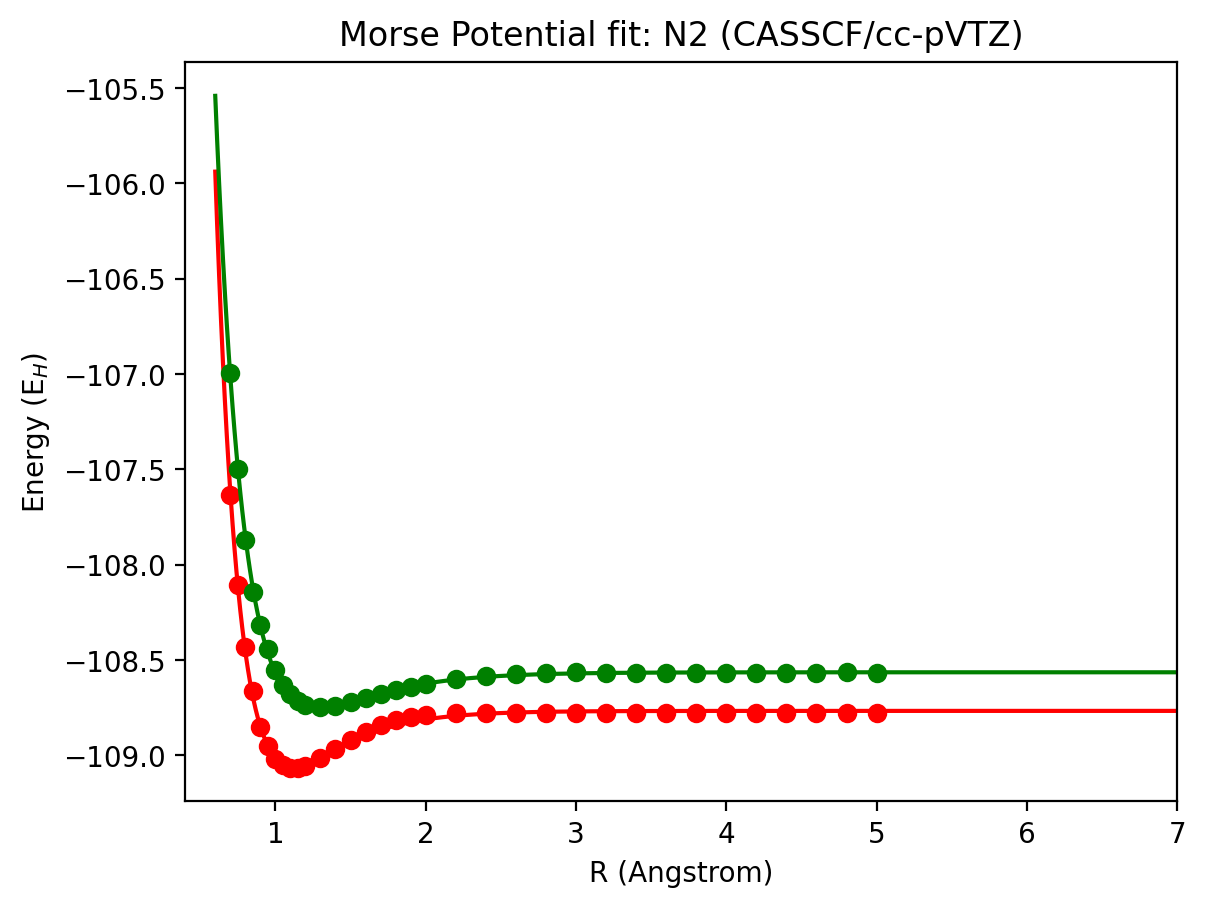

In [13]:
from scipy.optimize import curve_fit

xdata=np.array(N2_rlist)
ydata0=CAS_elist_0
ydata1=CAS_elist_1

t=np.linspace(0.6,7.0,500)

tstart = [0.1, 4, 1.10, -109.3]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt0, pcov0 = curve_fit(ms, xdata, ydata0, p0 = tstart,  maxfev=40000000)
#print(popt)
yfit0 = ms(t, popt0[0], popt0[1], popt0[2], popt0[3])
popt1, pcov1 = curve_fit(ms, xdata, ydata1, p0 = tstart,  maxfev=40000000)
#print(popt)
yfit1 = ms(t, popt1[0], popt1[1], popt1[2], popt1[3])



plt.plot(xdata, ydata0,"ro")
plt.plot(t, yfit0,'r-')
plt.plot(xdata, ydata1,"go")
plt.plot(t, yfit1,'g-')
plt.title("Morse Potential fit: N2 (CASSCF/cc-pVTZ)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.xlim(0.4,7.0)

dissociation_energy=(-min(yfit0)+yfit0[499])*27.211399

print(f"Predicted Equilibrium Bond Length: {popt0[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.0977 A")

print(f"Predicted Bond Dissociation Energy: {dissociation_energy:.4f} eV")
print("Known Bond Dissociation Energy: 9.759 eV")

In [34]:
# option to generate high-resolution matplotlib figures
%config InlineBackend.figure_format='retina'

import glob
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from forte2.orbitals import write_orbital_cubes

def _read_cube_data(cube_file):
    """Read enough of a Gaussian cube file to recover the volumetric data."""
    with open(cube_file, "r") as f:
        f.readline()
        f.readline()

        natoms = abs(int(f.readline().split()[0]))

        shape = []
        for _ in range(3):
            shape.append(abs(int(f.readline().split()[0])))

        for _ in range(natoms):
            f.readline()

        values = np.fromiter(
            (float(x) for line in f for x in line.split()),
            dtype=float,
        )

    expected = int(np.prod(shape))
    if values.size < expected:
        raise ValueError(
            f"Cube file {cube_file} has {values.size} data values, expected {expected}"
        )

    return values[:expected].reshape(shape)


def _signed_max_projection(data, axis=2):
    """Project a signed orbital volume while preserving the larger-magnitude sign."""
    axis = int(axis)
    max_idx = np.argmax(np.abs(data), axis=axis)
    return np.take_along_axis(
        data,
        np.expand_dims(max_idx, axis),
        axis=axis,
    ).squeeze(axis)


def plot_orbital_cube_projection(
    system,
    C,
    orbital,
    orbitals_filepath="orbital_cube_projection",
    projection_axis=0,
    cmap="seismic",
    levels=14,
    figsize=(4, 4),
    title=None,
    output_file=None,
):
    """Write one orbital cube and plot a signed 2D max projection.

    Parameters
    ----------
    system
        Forte2 system object.
    C
        MO coefficient matrix, e.g. `mc.C[0]`.
    orbital
        Orbital index to write and plot.
    orbitals_filepath
        Folder where the cube file is written.
    projection_axis
        Axis collapsed from the 3D cube. Common choices:
        0, 1, or 2.
    """
    orbitals_filepath = pathlib.Path(orbitals_filepath)
    orbitals_filepath.mkdir(parents=True, exist_ok=True)

    write_orbital_cubes(
        system,
        C,
        indices=[orbital],
        filepath=orbitals_filepath,
        prefix="orbital",
    )

    cube_files = glob.glob(str(orbitals_filepath / f"orbital_{orbital}.cube"))
    if not cube_files:
        cube_files = glob.glob(str(orbitals_filepath / "orbital_*.cube"))

    if not cube_files:
        raise FileNotFoundError(
            f"No cube file was written in {orbitals_filepath}"
        )

    cube_file = pathlib.Path(cube_files[0])
    data = _read_cube_data(cube_file)
    plane = _signed_max_projection(data, axis=projection_axis)

    vmax = float(np.max(np.abs(plane)))
    if vmax == 0.0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(
        plane.T,
        origin="lower",
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
    )

    contour_levels = np.linspace(-vmax, vmax, 2 * levels + 1)
    contour_levels = contour_levels[contour_levels != 0.0]

    if contour_levels.size:
        ax.contour(
            plane.T,
            levels=contour_levels,
            colors="black",
            linewidths=0.35,
            alpha=0.45,
        )

    ax.set_axis_off()

    if title is None:
        title = f"Orbital {orbital}"
    ax.set_title(title)

    #cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    #cbar.set_label("MO amplitude", rotation=270, labelpad=15)

    if output_file is not None:
        fig.savefig(output_file, bbox_inches="tight", dpi=300)

    plt.show()

    return fig, ax, cube_file

In [44]:
xyz = f"""
    N 0.000 0.000 0.000
    N 1.0977 0.000 0.000
    """

system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CISolver(forte2.State(nel=14, multiplicity=1, ms=0.0),
    active_orbitals=6,
    core_orbitals=4,
    nroots=6
)
mc = forte2.MCOptimizer(ci)(rhf)
mc.run()


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   2.07435237   0.00000000   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 3.101e+00
  Min eigenvalue: 6.136e-03
  Condition number: 5.054e+02
  Inverse condition number: 1.978e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 6.136e-03
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 158
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis function

MCOptimizer(ci_solver=CISolver(states=State(multiplicity=1, ms=0.0, nel=14, system=None, charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=7, nb=7, twice_ms=0), nroots=6, weights=[[0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]], mo_space=MOSpace(nmo=28, active_orbitals=[[4, 5, 6, 7, 8, 9]], core_orbitals=[0, 1, 2, 3], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=4, active_orbitals=6, frozen_virtual_orbitals=None, die_if_not_converged=False, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=4), active_frozen_orbitals=None, freeze_inter_gas_rots=False, maxiter=50, e_tol=1e-08, g_tol=1e-07, die_if


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [3]



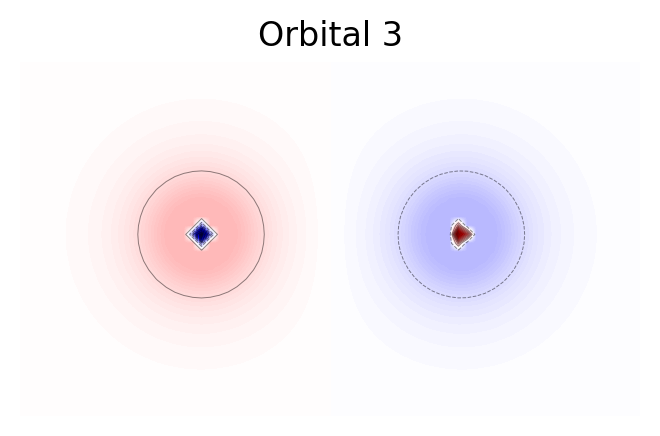


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [4]



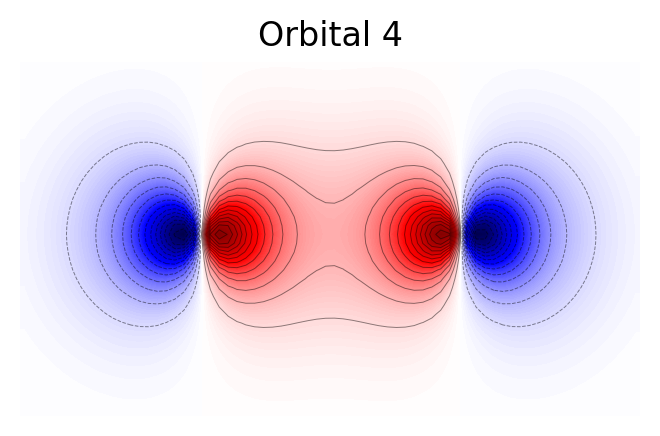


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [5]



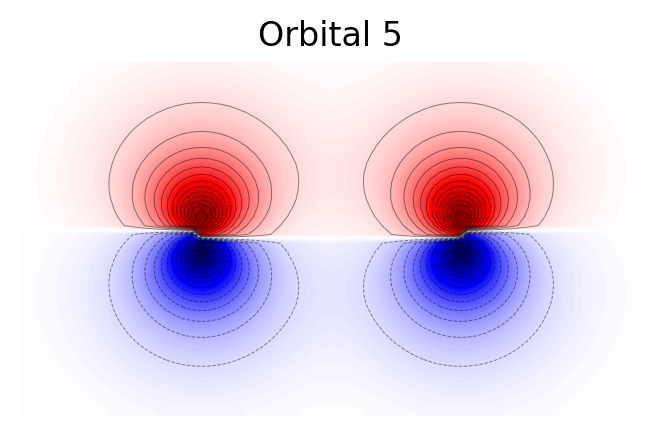


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [6]



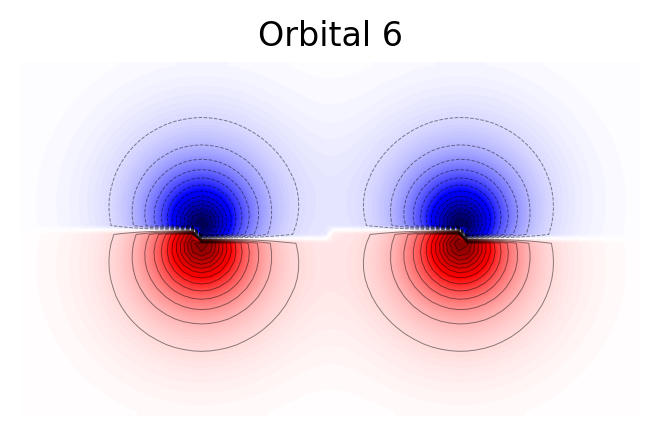


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [7]



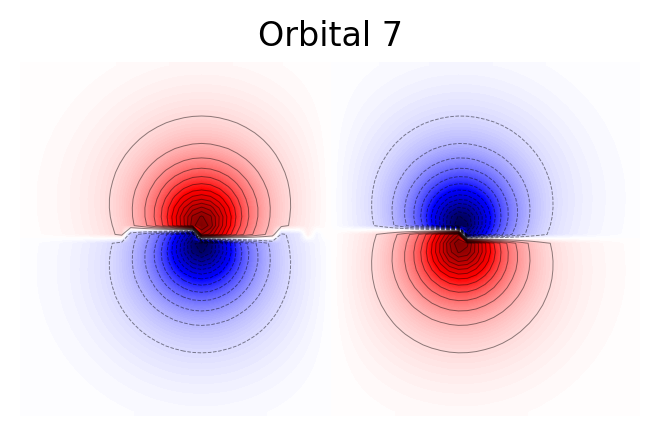


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [8]



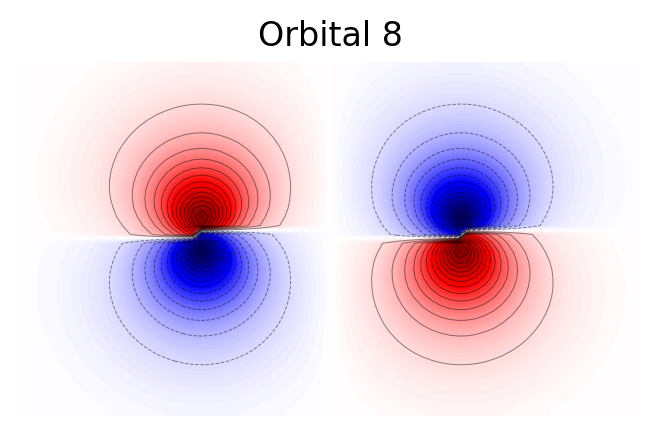


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [9]



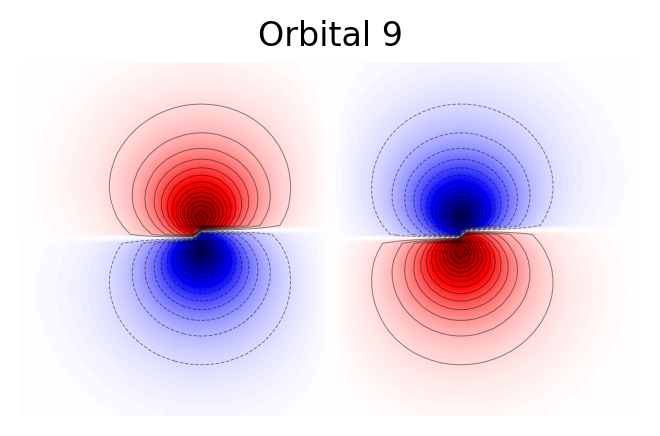


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 70 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [10]



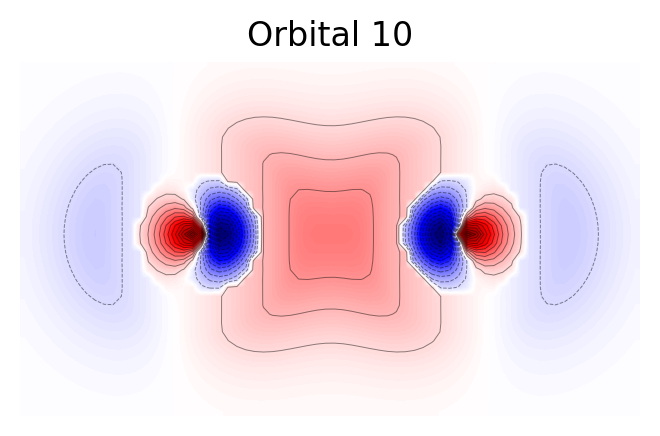

In [43]:
for i in range(3,11):
    plot_orbital_cube_projection(system=system,C=mc.C[0],orbital= i ,projection_axis=1)

In [16]:
N2_rlist = [0.70,0.75,0.80,0.85,0.90,0.95,1.00,1.05,1.0977,1.15,1.20,1.30,1.40,1.50,1.60, 1.70, 1.80, 1.90, 2.00, 2.20, 2.40,2.60, 2.80, 3.00,3.20, 3.40, 3.60, 3.80, 4.00, 4.20, 4.40, 4.60, 4.80, 5.00]
DSRG_elist = []
for i in range(0,len(N2_rlist)):
    xyz = f"""
    N 0.000 0.000 0.000
    N 0.000 0.000 {N2_rlist[i]}
    """

    system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")
    rhf = forte2.RHF(charge=0)(system)
    rhf.run()

    ci = forte2.CISolver(forte2.State(nel=14, multiplicity=1, ms=0.0),
        active_orbitals=6,
        core_orbitals=4,
        nroots=6
    )
    mc = forte2.MCOptimizer(ci)(rhf)
    mc.run()
    #CAS_elist.append(ci.E[0])
    dsrg = forte2.dsrg.DSRG_MRPT2(flow_param=0.5, relax_reference="once")(mc)
    dsrg.run()
    DSRG_elist.append(dsrg.E_relaxed_ref)
print(DSRG_elist)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   0.00000000   1.32280829
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 3.266e+00
  Min eigenvalue: 8.208e-04
  Condition number: 3.980e+03
  Inverse condition number: 2.513e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 8.208e-04
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 158
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis function

RuntimeError: Orbital optimization did not converge in 50 iterations.

Predicted Equilibrium Bond Length: 1.2363 A
Known Equilibrium Bond Length: 1.0977 A
Predicted Bond Dissociation Energy: 5.5618 eV
Known Bond Dissociation Energy: 9.759 eV


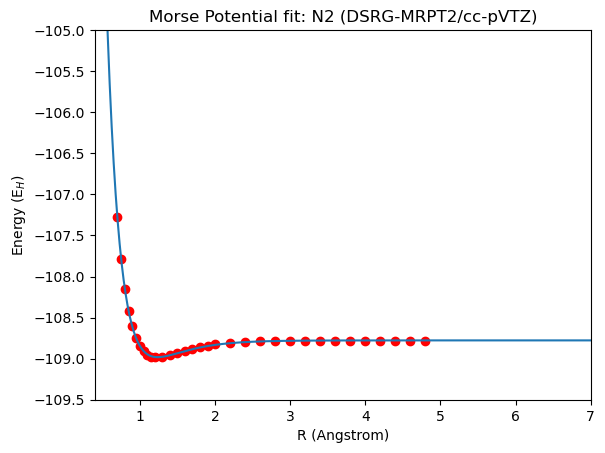

In [ ]:
xdata4=np.array(N2_rlist)
ydata4=DSRG_elist

t=np.linspace(0.4,7.0,500)

tstart = [5, 5, 1.1, -150]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt, pcov = curve_fit(ms, xdata4, ydata4, p0 = tstart,  maxfev=40000000)
#print(popt)
yfit = ms(t, popt[0], popt[1], popt[2], popt[3])

plt.plot(xdata4[:-1], ydata4[:-1],"ro")
plt.plot(t, yfit)
plt.title("Morse Potential fit: N2 (DSRG-MRPT2/cc-pVTZ)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.xlim(0.4,7.0)
plt.ylim(-109.5,-105)

dissociation_energy=(-min(yfit)+yfit[499])*27.211399

print(f"Predicted Equilibrium Bond Length: {popt[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.0977 A")

print(f"Predicted Bond Dissociation Energy: {dissociation_energy:.4f} eV")
print("Known Bond Dissociation Energy: 9.759 eV")

## Nickel Hydride

In [ ]:
#NiH experimental bond length: 1.454 Angstrom

NiH_rlist = [0.70,0.80,0.90,1.00,1.10,1.20,1.35,1.40,1.454,1.50,1.55,1.60,1.80,2.00,2.20, 2.40, 2.60, 2.80, 3.00,3.20, 3.40, 3.60, 3.80, 4.00, 4.20, 4.40, 4.60, 4.80, 5.00]
DSRG_elist = []
CAS_elist_0 =[]
CAS_elist_2 = []
CAS_elist_4 = []

for i in range(0,len(NiH_rlist)):
    xyz = f"""
    H 0.000 0.000 0.000
    Ni 0.000 0.000 {NiH_rlist[i]}
    """

    system = forte2.System(xyz=xyz, basis_set="def2-TZVP", auxiliary_basis_set="def2-universal-JKFIT")
    scf = forte2.ROHF(charge=0,ms=0.5)(system)
    scf.run()

    avas = forte2.AVAS(subspace=["Ni(4s)","Ni(3d)"],
                       selection_method="total",
                       num_active=7)(scf)
    
    ci = forte2.CISolver(forte2.State(nel=29, multiplicity=2, ms=0.5),
        active_orbitals=7,
        core_orbitals=9,
        nroots=7
    )
    mc = forte2.MCOptimizer(ci,maxiter=100)(avas)
    mc.run()
    CAS_elist_0.append(ci.E[0])
    CAS_elist_2.append(ci.E[2])
    CAS_elist_4.append(ci.E[4])

    dsrg = forte2.dsrg.DSRG_MRPT2(flow_param=0.5, relax_reference="iterate")(mc)
    dsrg.run()
    DSRG_elist.append(dsrg.E_relaxed_ref)
#print(DSRG_elist)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   NI   0.00000000   0.00000000   1.32280829
[forte2] Basis def2-tzvp not found locally. Using Basis Set Exchange.
[forte2] Basis def2-tzvp not found locally. Using Basis Set Exchange.
Parsed 2 atoms with basis set of 51 functions.
  Max eigenvalue: 4.485e+00
  Min eigenvalue: 1.896e-03
  Condition number: 2.366e+03
  Inverse condition number: 4.227e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 51
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.896e-03
Number of electrons: 29
Number of alpha electrons: 15
Number of beta electrons: 14
Ms: 0.5
Total charge: 0
Number of basis functions: 51
Number of orthogonalized basis functions: 51
Number of auxiliary basis functions: 282
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF S

Predicted Equilibrium Bond Length, CAS: 1.5008 A
Predicted Equilibrium Bond Length, DSRG: 1.5658 A
Known Equilibrium Bond Length: 1.454 A
Predicted Bond Dissociation Energy, CAS: 1.9114 eV
Predicted Bond Dissociation Energy, DSRG: 1.3390 eV
Known Bond Dissociation Energy: 2.70 eV


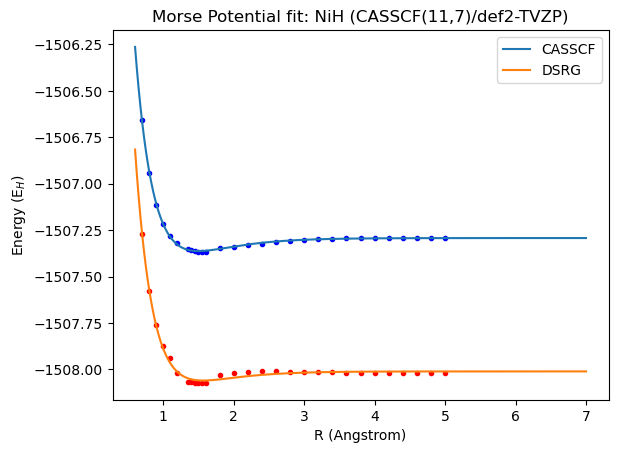

In [ ]:
xdat=np.array(NiH_rlist)
ydat0=CAS_elist_0
ydat1=DSRG_elist

t=np.linspace(0.6,7.0,500)

tstart = [0, 1, 1.5, -1500]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt0, pcov0 = curve_fit(ms, xdat, ydat0, p0 = tstart,  maxfev=40000000)
yfit0 = ms(t, popt0[0], popt0[1], popt0[2], popt0[3])
popt1, pcov1 = curve_fit(ms, xdat, ydat1, p0 = tstart,  maxfev=40000000)
yfit1 = ms(t, popt1[0], popt1[1], popt1[2], popt1[3])

plt.plot(xdat, ydat0,"b.")
plt.plot(t, yfit0,label=r"CASSCF")
plt.plot(xdat, ydat1,"r.")
plt.plot(t, yfit1,label=r"DSRG")
plt.title("Morse Potential fit: NiH (CASSCF(11,7)/def2-TVZP)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.legend()

dissociation_energy_CAS=(-min(yfit0)+yfit0[499])*27.211399
dissociation_energy_DSRG=(-min(yfit1)+yfit1[499])*27.211399
print(f"Predicted Equilibrium Bond Length, CAS: {popt0[2]:.4f} A")
print(f"Predicted Equilibrium Bond Length, DSRG: {popt1[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.454 A")

print(f"Predicted Bond Dissociation Energy, CAS: {dissociation_energy_CAS:.4f} eV")
print(f"Predicted Bond Dissociation Energy, DSRG: {dissociation_energy_DSRG:.4f} eV")
print("Known Bond Dissociation Energy: 2.70 eV")

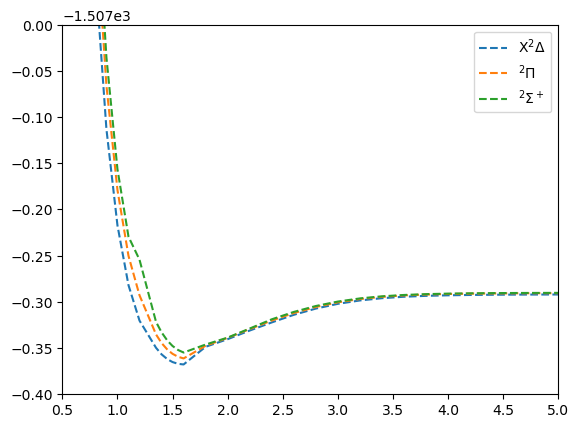

In [ ]:
plt.plot(NiH_rlist,CAS_elist_0,'--',label=r"X$^2 \Delta $")
plt.plot(NiH_rlist,CAS_elist_2,'--',label=r"$^2 \Pi $")
plt.plot(NiH_rlist,CAS_elist_4,'--',label=r"$^2 \Sigma^+$")
plt.xlim((0.5,5))
plt.ylim((-1507.4,-1507.0))
plt.legend()

Predicted Equilibrium Bond Length: 1.4996 A
Known Equilibrium Bond Length: 1.0977 A
Predicted Bond Dissociation Energy: 1.8357 eV
Known Bond Dissociation Energy: 9.759 eV


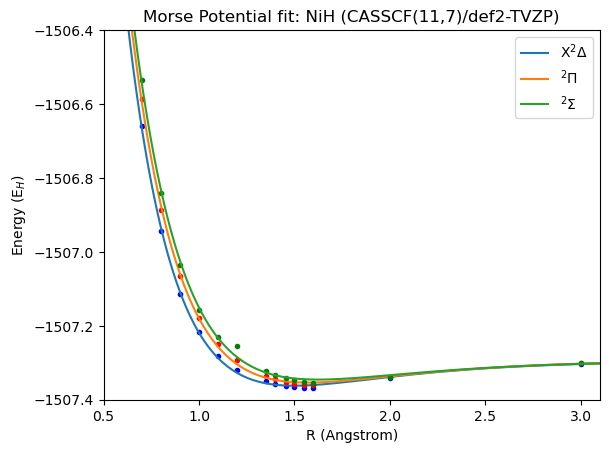

In [ ]:
xdat=np.array(NiH_rlist)
ydat0=CAS_elist_0
ydat1=CAS_elist_1
ydat2=CAS_elist_2

t=np.linspace(0.6,7.0,500)

tstart = [0, 1, 1.5, -1500]
def ms(x, D, a, re, b):
    return D*(1 - np.exp(-a*(x-re)))**2 -b

popt0, pcov0 = curve_fit(ms, xdat, ydat0, p0 = tstart,  maxfev=40000000)
yfit0 = ms(t, popt0[0], popt0[1], popt0[2], popt0[3])
popt1, pcov1 = curve_fit(ms, xdat, ydat1, p0 = tstart,  maxfev=40000000)
yfit1 = ms(t, popt1[0], popt1[1], popt1[2], popt1[3])
popt2, pcov2 = curve_fit(ms, xdat, ydat2, p0 = tstart,  maxfev=40000000)
yfit2 = ms(t, popt2[0], popt2[1], popt2[2], popt2[3])

plt.plot(xdat, ydat0,"b.")
plt.plot(t, yfit0,label=r"X$^2\Delta$")
plt.plot(xdat, ydat1,"r.")
plt.plot(t, yfit1,label=r"$^2\Pi$")
plt.plot(xdat, ydat2,"g.")
plt.plot(t, yfit2,label=r"$^2\Sigma$")
plt.title("Morse Potential fit: NiH (CASSCF(11,7)/def2-TVZP)")
plt.xlabel("R (Angstrom)")
plt.ylabel("Energy (E$_{H}$)")
plt.ticklabel_format(useOffset=False)
plt.xlim(0.5,3.1)
plt.ylim(-1507.4,-1506.4)
plt.legend()

dissociation_energy=(-min(yfit0)+yfit0[499])*27.211399

print(f"Predicted Equilibrium Bond Length: {popt0[2]:.4f} A")
print("Known Equilibrium Bond Length: 1.0977 A")

print(f"Predicted Bond Dissociation Energy: {dissociation_energy:.4f} eV")
print("Known Bond Dissociation Energy: 9.759 eV")

Text(0.5, 1.0, 'CCSD with Quasi-Restricted HF /aug-cc-pVTZ')

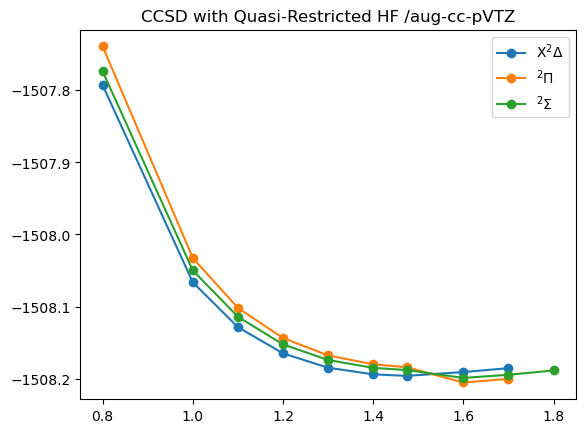

In [ ]:
nih_rvals = [0.80,1.00,1.10,1.20,1.30,1.40,1.474,1.60,1.70,1.80,2.00,2.50,3.00]
delta_ground = [-1507.792806962752,-1508.066476869061,-1508.128589133811,-1508.164941373709,-1508.184875470200,-1508.194096407682,-1508.196164722938,-1508.190895326469,-1508.185510085776]
pi_ground = [-1507.739155078413,-1508.032625073124,-1508.101838428880,-1508.143671811301,-1508.167774823533,-1508.180167592974,-1508.184104837737,-1508.205359162498,-1508.200415936185]
sigma_ground = [-1507.773696754461,-1508.049970091690,-1508.114117716761,-1508.152486578651,-1508.174229352979,-1508.185035383355,-1508.188150890325,-1508.199023205993,-1508.194671774991,-1508.188711650117]
plt.plot(nih_rvals[0:9],delta_ground,'-o',label=r"X$^2\Delta$")
plt.plot(nih_rvals[0:9],pi_ground,'-o',label=r"$^2\Pi$")
plt.plot(nih_rvals[0:10],sigma_ground,'-o',label=r"$^2\Sigma$")
plt.legend()
plt.title("CCSD with Quasi-Restricted HF /aug-cc-pVTZ")